In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import shutil

from scipy import stats, integrate
from scipy.fft import rfft, rfftfreq
import gc

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [2]:
# ============================================================
# 0. CONSTANTS
# ============================================================
ROOT = "/kaggle/input/datasets/vuxuancu/mafaulda-full/mafaulda"
SAMPLE_RATE = 51200   # Hz
WINDOW_SIZE = 8192   # للسرعة القصوى
OVERLAP_STEP = 8192   # بدون تداخل لتوفير مساحة الـ Disk في كاجل

COLUMNS = [
    'tachometer',
    'underhang_axial', 'underhang_radial', 'underhang_tangential',
    'overhang_axial',  'overhang_radial',  'overhang_tangential',
    'microphone'
]

# SKF 6205 bearing specs
N_BALLS       = 8         
D_BALL        = 0.7145   
D_PITCH       = 2.8519  
CONTACT_ANGLE = 0


BPFO_RATIO = 2.9980
BPFI_RATIO = 5.0020
BSF_RATIO  = 1.8710
FTF_RATIO  = 0.3750

In [3]:
# 1. الثوابت  
records_index = []

print(">>> Scanning and Indexing all files...")

for fault_type in os.listdir(ROOT):
    fault_path = os.path.join(ROOT, fault_type)
    if not os.path.isdir(fault_path): continue
    for root, dirs, files in os.walk(fault_path):
        for f in files:
            if f.endswith(".csv"):
                full_path = os.path.join(root, f)
                for start_row in range(0, 250000 - WINDOW_SIZE, OVERLAP_STEP):
                    records_index.append({
                        "label": fault_type,
                        "filepath": full_path,
                        "start_row": start_row,
                        "sub_label": os.path.basename(root)
                    })

# --- التعديل الجوهري هنا ---
# 2. تحويل القائمة لـ DataFrame
data_index = pd.DataFrame(records_index)

# 3. اللخبطة الكاملة (Shuffle) لكل الداتا
# frac=1 يعني لخبطة كل الصفوف، random_state لضمان تكرار نفس النتيجة
data_index = data_index.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. حفظ الـ Index كاحتياط (مهم جداً في كاجل لو الـ session فصلت)
data_index.to_csv("final_data_index_map.csv", index=False)

print(f"✅ Kaggle Indexing Complete: {len(data_index)} windows generated and shuffled.")

>>> Scanning and Indexing all files...
✅ Kaggle Indexing Complete: 58530 windows generated and shuffled.


In [ ]:
def extract_and_save_data(signal, rpm, window_id, fs=51200):
    """
    تعديل Kaggle النهائي: معالجة شاملة لـ 58,000 نافذة
    - حفظ فيزياء (float16) لتوفير المساحة
    - استخراج ميزات خبيرة (Expert Features)
    - ربط المسار بالـ window_id الجديد بعد الـ Shuffle
    """
    # تحويل الإشارة لمصفوفة نمباي وتوسيطها (Zero-centering)
    signal = np.array(signal, dtype=np.float32)
    signal = signal - np.mean(signal) 
    
    # --- 1. ميزات المجال الزمني (Time Domain) ---
    rms = np.sqrt(np.mean(signal**2))
    kurt = stats.kurtosis(signal)
    skew = stats.skew(signal)
    crest = np.max(np.abs(signal)) / (rms + 1e-10)
    
    # --- 2. ميزات المجال الترددي (Frequency Domain - FFT) ---
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal)) / n
    freqs = np.fft.rfftfreq(n, 1/fs)
    f_base = rpm / 60.0 # التردد الأساسي للهيرتز

    def get_peak_info(f_target, width=2.5):
        # البحث عن أعلى قمة حول التردد المطلوب (1x, 2x, 3x)
        mask = (freqs >= f_target - width) & (freqs <= f_target + width)
        return np.max(fft_vals[mask]) if np.any(mask) else 0.0

    p_1x = get_peak_info(f_base)
    p_2x = get_peak_info(2 * f_base)
    p_3x = get_peak_info(3 * f_base)
    ratio_2x_1x = p_2x / (p_1x + 1e-10)
    total_spectral_energy = np.sum(fft_vals**2)

    # --- 3. حساب مصفوفات الفيزياء (Pre-calculating Physics) ---
    dt = 1.0 / fs
    # التكامل للحصول على السرعة والإزاحة
    vel = integrate.cumulative_trapezoid(signal, dx=dt, initial=0).astype(np.float32)
    disp = integrate.cumulative_trapezoid(vel, dx=dt, initial=0).astype(np.float32)
    t = np.linspace(0, len(signal) * dt, len(signal), dtype=np.float32)

    # --- 4. الحفظ الذكي بنظام الـ IDs الجديدة ---
    # الـ window_id هنا هو الـ index الجديد من الـ Shuffled DataFrame
    npy_filename = f"win_{window_id}.npy"
    npy_path = os.path.join(NPY_DIR, npy_filename)
    
    # تجميع (Stacking): [Acceleration, Velocity, Displacement, Time]
    # الحفظ بصيغة float16 بيقلل حجم الـ 119 ألف ملف من 8 جيجا لـ 4 جيجا تقريباً
    physics_bundle = np.stack([signal, vel, disp, t]).astype(np.float16)
    np.save(npy_path, physics_bundle)

    # إرجاع القاموس لتحديث الـ DataFrame الرئيسي
    return {
        "rms": rms,
        "kurtosis": kurt,
        "skewness": skew,
        "crest_factor": crest,
        "p_1x": p_1x,
        "p_2x": p_2x,
        "p_3x": p_3x,
        "ratio_2x_1x": ratio_2x_1x,
        "total_energy": total_spectral_energy,
        "npy_path": npy_path, # المسار الفيزيائي للملف على الهارد
        "rpm": rpm
    }

In [5]:
# 1. تعريف المسار (Kaggle Working Directory)
NPY_DIR = "/kaggle/working/mafaulda_processed_npy"

# 2. إنشاء المجلد "على نظافة" 
# طالما هترني الـ 119 ألف مرة واحدة، لازم نمسح أي تجارب قديمة
if os.path.exists(NPY_DIR):
    print(f"🧹 Cleaning existing directory to prevent data overlap: {NPY_DIR}")
    shutil.rmtree(NPY_DIR) 

# إنشاء المجلد من جديد
os.makedirs(NPY_DIR, exist_ok=True)
print(f"📁 Created fresh directory: {NPY_DIR}")

print("✅ System Ready. You can now start the 58,000 extraction loop.")

📁 Created fresh directory: /kaggle/working/mafaulda_processed_npy
✅ System Ready. You can now start the 58,000 extraction loop.


In [6]:
if os.path.exists(NPY_DIR):
    shutil.rmtree(NPY_DIR)
    print(f"Cleaning old files from: {NPY_DIR}\n")
os.makedirs(NPY_DIR, exist_ok=True)

# frac=1 تعني كل الصفوف، random_state لضمان ثبات النتيجة
data_index_shuffled = data_index.sample(frac=1, random_state=42).reset_index(drop=True)

print(f">>> Starting processing FULL DATASET ({len(data_index_shuffled)} windows)")
feature_records = []

# 3. التعديل الثاني: إزالة الـ LIMIT واستخدام الـ index الجديد (i) كمعرف للملف
# التعديل الثالث: استخدام data_index_shuffled بدلاً من data_index
for i, row in data_index_shuffled.iterrows():
    feat_row = {
        "label":      row["label"],
        "sub_label":  row.get("sub_label", "none"),
        "filepath":   row["filepath"],
        "start_row":  row["start_row"] 
    }

    try:
        # قراءة النافذة
        df_temp = pd.read_csv(
            row["filepath"], 
            header=None, 
            names=COLUMNS, 
            skiprows=row["start_row"], 
            nrows=8192 # WINDOW_SIZE
        )
        
        # حساب الـ RPM
        tach = df_temp["tachometer"].values.astype(float)
        tach_centered = tach - np.mean(tach)
        zero_crossings = np.where(np.diff(np.sign(tach_centered)))[0]
        
        if len(zero_crossings) > 1:
            avg_period_samples = np.mean(np.diff(zero_crossings)) * 2
            rpm = (51200 / avg_period_samples) * 60
        else:
            rpm = 1800.0 # Fallback

        # استخراج الميزات وحفظ ملف الفيزياء (window_id=i يضمن الترتيب 0, 1, 2...)
        signal = df_temp["underhang_radial"].values
        expert_dict = extract_and_save_data(signal, rpm=rpm, window_id=i, fs=51200)
        
        feat_row.update(expert_dict)
        feature_records.append(feat_row)
        
        # متابعة التقدم كل 5000 عينة (عشان ميزحمش الـ Logs في كاجل)
        if len(feature_records) % 5000 == 0:
            print(f"Proccessed {len(feature_records)} / {len(data_index_shuffled)} windows")
            gc.collect() # مهم جداً لمنع الـ Memory Leak

    except Exception as e:
        # طباعة الخطأ فقط لو حصلت مشكلة حقيقية
        if i % 1000 == 0:
            print(f"❌ Error at index {i}: {e}")

# تحويل النتائج لـ DataFrame النهائي للميزات
features_df = pd.DataFrame(feature_records)

# تنظيف نهائي
gc.collect()

print(f"\n FULL PROCESSING COMPLETE!")
print(f"Total processed: {len(features_df)} windows.")
# تأكيد عدد الملفات على الهارد
!ls {NPY_DIR} | wc -l

Cleaning old files from: /kaggle/working/mafaulda_processed_npy

>>> Starting processing FULL DATASET (58530 windows)
Proccessed 5000 / 58530 windows
Proccessed 10000 / 58530 windows
Proccessed 15000 / 58530 windows
Proccessed 20000 / 58530 windows
Proccessed 25000 / 58530 windows
Proccessed 30000 / 58530 windows
Proccessed 35000 / 58530 windows
Proccessed 40000 / 58530 windows
Proccessed 45000 / 58530 windows
Proccessed 50000 / 58530 windows
Proccessed 55000 / 58530 windows

 FULL PROCESSING COMPLETE!
Total processed: 58530 windows.
58530


In [7]:
features_df.to_csv("final_features_full.csv", index=False)
print("✅ Features DataFrame saved to disk!")

✅ Features DataFrame saved to disk!


In [8]:
print(">>> Preprocessing & Multi-Target Setup ...")

excluded_cols = ["label", "sub_label", "filepath", "npy_path", "start_row", "rpm"]

feat_cols = [c for c in features_df.columns if c not in excluded_cols]

# 2. تحويل الـ Labels لأرقام (Fault Type)
le_label = LabelEncoder()
features_df["y_label"] = le_label.fit_transform(features_df["label"])

# 3. معالجة الـ Severity (Sub-label)
le_sev = LabelEncoder()
features_df["y_sev"] = le_sev.fit_transform(features_df["sub_label"].astype(str))

# 4. ملء أي قيم مفقودة في الجدول بالكامل قبل التقسيم (لضمان الأمان)
features_df[feat_cols] = features_df[feat_cols].fillna(0)

# 5. التقسيم (Split)
indices = np.arange(len(features_df))
train_idx, test_idx = train_test_split(
    indices, 
    test_size=0.2, 
    random_state=42, 
    stratify=features_df["y_label"]
)

# 6. الـ Scaler
scaler = StandardScaler()
# التدريب على الـ Train فقط
scaler.fit(features_df.iloc[train_idx][feat_cols])

print(f"Preprocessing Complete for {len(features_df)} samples.")
print(f"Features to be scaled ({len(feat_cols)}): {feat_cols}")
print(f"Training samples: {len(train_idx)}, Test samples: {len(test_idx)}")
print(f"RPM is kept raw for Physics calculations.")

# حفظ نسخة من الـ labels عشان لو حبينا نرجع للأسماء الأصلية بعدين
label_mapping = dict(zip(le_label.transform(le_label.classes_), le_label.classes_))
print(f"Classes detected: {label_mapping}")

>>> Preprocessing & Multi-Target Setup ...
Preprocessing Complete for 58530 samples.
Features to be scaled (9): ['rms', 'kurtosis', 'skewness', 'crest_factor', 'p_1x', 'p_2x', 'p_3x', 'ratio_2x_1x', 'total_energy']
Training samples: 46824, Test samples: 11706
RPM is kept raw for Physics calculations.
Classes detected: {np.int64(0): 'horizontal-misalignment', np.int64(1): 'imbalance', np.int64(2): 'normal', np.int64(3): 'overhang', np.int64(4): 'underhang', np.int64(5): 'vertical-misalignment'}


In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment is Ready. Device: {DEVICE}")

Environment is Ready. Device: cuda


In [10]:
class MafauldaHybridDataset(Dataset):
    def __init__(self, features_df, scaler, feat_cols):
        self.df = features_df.reset_index(drop=True)
        self.scaler = scaler
        self.feat_cols = feat_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. تحميل ملف الـ Numpy وتحويله لـ float32
        # (بما إننا في كاجل حفظنا float16، التحويل هنا ضروري للحسابات الدقيقة)
        try:
            data_bundle = np.load(row['npy_path']).astype(np.float32)
        except Exception as e:
            # تأمين إضافي لو فيه ملف باظ أثناء الاستخراج الطويل
            print(f"Error loading file {row['npy_path']}: {e}")
            return None 

        acc  = data_bundle[0]
        vel  = data_bundle[1]
        disp = data_bundle[2]
        t    = data_bundle[3]
        
        # 2. تجهيز الميزات الإحصائية (Expert Features)
        feats_raw = row[self.feat_cols].values.reshape(1, -1)
        feats_raw = np.nan_to_num(feats_raw.astype(np.float32)) 
        feats_scaled = self.scaler.transform(feats_raw).flatten()
        
        # 3. حساب الأوميجا (التردد الزاوي)
        # Omega = 2 * pi * f (حيث f هي التردد بالهرتز)
        omega = 2 * np.pi * (row['rpm'] / 60.0)

        # 4. التحويل لـ Tensors
        # [تعديل هام]: تفعيل requires_grad لـ t ضروري لحساب معادلة الفيزياء لاحقاً
        t_tensor = torch.from_numpy(t)
        
        return {
            "x_acc": torch.from_numpy(acc),
            "x_vel": torch.from_numpy(vel),
            "x_disp": torch.from_numpy(disp),
            "t": t_tensor, # سنفعل requires_grad_ في الـ Training Loop لتوفير الذاكرة
            "features": torch.from_numpy(feats_scaled),
            "omega": torch.as_tensor(omega, dtype=torch.float32),
            "label": torch.as_tensor(row['y_label'], dtype=torch.long)
        }

In [11]:
# 1. بناء الـ Dataset Objects
print(">>> Creating Optimized Dataset Objects for Full Dataset...")

train_ds = MafauldaHybridDataset(
    features_df=features_df.iloc[train_idx], 
    scaler=scaler, 
    feat_cols=feat_cols
)

test_ds = MafauldaHybridDataset(
    features_df=features_df.iloc[test_idx], 
    scaler=scaler, 
    feat_cols=feat_cols
)

# 2. تجهيز الـ Loaders
BATCH_SIZE = 64 

train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,      
    pin_memory=True,     
    drop_last=True      # [تعديل هام] لضمان استقرار الـ Gradients والـ BatchNorm
)

test_loader = DataLoader(
    test_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False     # في التيست مش بنمسح حاجة، عايزين نقيم الداتا كلها
)

print(f"Training set size: {len(train_ds)}")
print(f"Test set size: {len(test_ds)}")
print(f"DataLoaders are ready. Total Batches: {len(train_loader)}")

>>> Creating Optimized Dataset Objects for Full Dataset...
Training set size: 46824
Test set size: 11706
DataLoaders are ready. Total Batches: 731


# HybridPINN_CNN

In [26]:
class HybridPINN_CNN(nn.Module):
    def __init__(self, n_classes=6, n_stat_features=None): 
        super(HybridPINN_CNN, self).__init__()
        
        # التأكد من عدد الميزات الإحصائية
        if n_stat_features is None:
            n_stat_features = len(feat_cols)
        
        # --- 1. الفرع الأول: 1D-CNN (بصمة الإشارة الخام) ---
        self.cnn_branch = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # بيحول المخرج لـ [batch, 32, 1] مهما كان طول الإشارة
        )
        
        # --- 2. الفرع الثاني: Expert Features (الميزات الخبيرة) ---
        self.stat_branch = nn.Sequential(
            nn.Linear(n_stat_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # --- 3. تجميع الملامح (Classification Head) ---
        self.combined_fc = nn.Sequential(
            nn.Linear(32 + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # حماية ضد الـ Overfitting
            nn.Linear(64, n_classes) 
        )
        
        # --- 4. الفرع الثالث: PINN Decoder (Physics Head) ---
        # بياخد (Time, Omega) وبيطلع الإزاحة المتوقعة
        self.pinn_decoder = nn.Sequential(
            nn.Linear(2, 64), 
            nn.Tanh(), # Tanh ضرورية للاشتقاق الفيزيائي لاحقاً      
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1) 
        )
        
        # بارامترات الفيزياء القابلة للتعلم (m, c, k)
        # بدأنا بقيم تقريبية والـ Loss هيخلي الموديل يظبطها
        self.log_m = nn.Parameter(torch.tensor([0.0])) 
        self.log_c = nn.Parameter(torch.tensor([-2.0]))
        self.log_k = nn.Parameter(torch.tensor([2.0]))

    def forward(self, raw_sig, stat_feats, t, omega):
        # أ. استخراج ملامح الـ CNN
        # raw_sig: [batch, 4096]
        cnn_out = self.cnn_branch(raw_sig.unsqueeze(1)) 
        cnn_out = cnn_out.view(cnn_out.size(0), -1) # [batch, 32]
        
        # ب. استخراج ملامح الـ Stat Branch
        stat_out = self.stat_branch(stat_feats) # [batch, 16]
        
        # ج. قرار التشخيص (Logits)
        combined = torch.cat((cnn_out, stat_out), dim=1) # [batch, 48]
        logits = self.combined_fc(combined)
        
        # د. تنبؤ الفيزياء (PINN)
        # t: [batch, 4096], omega: [batch]
        t_input = t.unsqueeze(-1) # [batch, 4096, 1]
        
        # توسيع omega ليتناسب مع كل نقطة زمنية
        omega_input = omega.view(-1, 1, 1).expand(-1, t.size(1), 1) # [batch, 4096, 1]
        
        pinn_combined_input = torch.cat([t_input, omega_input], dim=-1) # [batch, 4096, 2]
        
        # تنبؤ الإزاحة (pred_disp)
        pred_disp = self.pinn_decoder(pinn_combined_input).squeeze(-1) # [batch, 4096]
        
        return logits, pred_disp

In [27]:
def compute_physics_loss(model, pred_disp, t, omega):
    """
    حساب الخطأ الفيزيائي بناءً على قانون نيوتن للحركة:
    m*x'' + c*x' + k*x = F(t)
    """
    # 1. حساب السرعة (v) كـ مشتقة أولى للإزاحة بالنسبة للزمن
    # استخدام only_inputs=True بيسرع العملية جداً في كاجل
    v_pred = torch.autograd.grad(
        pred_disp, t, 
        grad_outputs=torch.ones_like(pred_disp),
        create_graph=True, 
        retain_graph=True,
        only_inputs=True
    )[0]
    
    # 2. حساب العجلة (a) كـ مشتقة ثانية (مشتقة السرعة بالنسبة للزمن)
    a_pred = torch.autograd.grad(
        v_pred, t, 
        grad_outputs=torch.ones_like(v_pred),
        create_graph=True, 
        retain_graph=True,
        only_inputs=True
    )[0]

    # 3. استخراج المعاملات الفيزيائية (Mass, Damping, Stiffness)
    # استخدام torch.exp بيضمن إن المعاملات دي تفضل دايماً موجبة فيزيائياً
    m = torch.exp(model.log_m)
    c = torch.exp(model.log_c)
    k = torch.exp(model.log_k)
    
    # 4. حساب القوة الخارجية (Excitation Force)
    # F(t) = cos(omega * t)
    # التأكد من توافق الأبعاد Batch Multiplication
    if omega.dim() == 1:
        omega_reshaped = omega.unsqueeze(-1) # [batch, 1]
    else:
        omega_reshaped = omega
        
    force = torch.cos(omega_reshaped * t) # [batch, 4096]
    
    # 5. حساب المتبقي (Physics Residual)
    # المعادلة: m*a + c*v + k*x - F = 0
    physics_residual = (m * a_pred) + (c * v_pred) + (k * pred_disp) - force
    
    # 6. المخرج هو MSE الـ Residual
    # ده اللي بيخلي الموديل "يتعلم" الفيزياء بجانب التشخيص
    return torch.mean(physics_residual**2)

In [28]:
# 1. حساب الأوزان ديناميكياً لمعالجة مشكلة الـ Class Imbalance

# حساب عدد العينات لكل كلاس (Fault Type)
counts = np.bincount(features_df["y_label"])
class_counts = torch.from_numpy(counts).float() 

# حساب الأوزان باستخدام مقلوب التكرار (Inverse Frequency)
# بنضيف 1e-6 عشان نضمن إننا مش هنقسم على صفر لو فيه كلاس ملوش عينات
weights_calculated = 1.0 / (class_counts + 1e-6)

# عمل Normalization للأوزان عشان تحافظ على استقرار الـ Loss
weights_calculated = (weights_calculated / weights_calculated.sum()) * len(class_counts)

# نقل الأوزان للجهاز (GPU) فوراً
weights_tensor = weights_calculated.to(DEVICE)

# عرض الأوزان للتأكد
print(">>> Dynamic Class Weights Calculated:")
for i, weight in enumerate(weights_calculated):
    fault_name = le_label.inverse_transform([i])[0]
    print(f"   - {fault_name:25}: {weight.item():.4f}")

print(f"\n✅ Weights ready on {DEVICE}")

>>> Dynamic Class Weights Calculated:
   - horizontal-misalignment  : 0.8567
   - imbalance                : 0.5068
   - normal                   : 3.4443
   - overhang                 : 0.3290
   - underhang                : 0.3025
   - vertical-misalignment    : 0.5607

✅ Weights ready on cuda


In [29]:
# 2. بناء الموديل الهجين
# سيتعرف تلقائياً على عدد الميزات (Expert Features) من feat_cols
model = HybridPINN_CNN(n_classes=6, n_stat_features=len(feat_cols)) 
model = model.to(DEVICE)

# 3. إعداد دوال الخسارة (Loss Functions)
# خسارة التصنيف مع معالجة عدم التوازن (Imbalance)
weights_tensor = weights_calculated.to(DEVICE)
criterion_cls = nn.CrossEntropyLoss(weight=weights_tensor)

# خسارة مطابقة البيانات (Data-Driven Loss) لفرع الإزاحة
# نستخدم MSELoss لمقارنة pred_disp مع true_disp (المستخرجة من الـ npy)
criterion_data = nn.MSELoss()

# 4. المحسن (Optimizer) والجدول الزمني (Scheduler)
# Adam هو المحرك المثالي للـ PINNs في البداية
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# الـ Scheduler ده ذكي جداً؛ لو الـ Loss ثبتت 3 Epochs، هيقلل الـ Learning Rate للنص
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3
)

print(f"🚀 Hybrid PINN-CNN Model is deployed on: {DEVICE}")
print(f"📊 Features used: {len(feat_cols)} | Classes: 6")
print(f"✅ Ready for the Final Training Loop.")

🚀 Hybrid PINN-CNN Model is deployed on: cuda
📊 Features used: 9 | Classes: 6
✅ Ready for the Final Training Loop.


In [30]:
# le_label = LabelEncoder()
# features_df["y_label"] = le_label.fit_transform(features_df["label"])
# le_sev = LabelEncoder()
# features_df["y_sev"] = le_sev.fit_transform(features_df["sub_label"].astype(str))

# indices = np.arange(len(features_df))
# train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=features_df["y_label"])

# scaler = StandardScaler()
# feat_cols = [c for c in features_df.columns if c not in ["label", "sub_label", "npy_path", "y_label", "y_sev", "rpm"]]
# scaler.fit(features_df.iloc[train_idx][feat_cols].fillna(0))

# train_ds = MafauldaHybridDataset(features_df.iloc[train_idx], scaler, feat_cols)
# test_ds = MafauldaHybridDataset(features_df.iloc[test_idx], scaler, feat_cols)

# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0) # num_workers=0 أضمن في كاجل لو فيه File Errors
# test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
# print("✅ DataLoaders Ready!")

In [31]:
def train_hybrid_model(model, train_loader, epochs=20):
    history = {
        'train_loss': [], 'train_acc': [],
        'cls_loss': [], 'phys_loss': [], 'data_loss': []
    }
    
    print(f">>> Starting Training on {DEVICE} (Kaggle Optimized)...")

    

    for epoch in range(epochs):
        model.train()
        total_loss, total_cls, total_phys, total_data = 0, 0, 0, 0
        correct, total_samples = 0, 0
        
        # --- Physics Warm-up (وزن الفيزياء بيزيد تدريجياً) ---
        if epoch < 5:
            lambda_phys = 0.001 # نركز في الأول على التصنيف
        elif epoch < 12:
            lambda_phys = 0.01
        else:
            lambda_phys = 0.1   # نضغط بقوانين الفيزياء في الآخر
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            # 1. نقل البيانات وتفعيل الـ Gradients للزمن t
            x_acc = batch['x_acc'].to(DEVICE)
            t = batch['t'].to(DEVICE).requires_grad_(True)
            omega = batch['omega'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            true_disp = batch['x_disp'].to(DEVICE)
            features = batch['features'].to(DEVICE)
                
            # 2. Forward Pass
            logits, pred_disp = model(x_acc, features, t, omega)
            
            # 3. حساب الـ Hybrid Losses
            loss_cls = criterion_cls(logits, labels)
            loss_data = criterion_data(pred_disp, true_disp) # مطابقة البيانات
            loss_phys = compute_physics_loss(model, pred_disp, t, omega) # معادلة نيوتن
            
            # 4. تجميع الخسارة الكلية (وزن 5.0 للإزاحة لتقوية الإشارة الضعيفة)
            total_batch_loss = loss_cls + (5.0 * loss_data) + (lambda_phys * loss_phys)
            
            # 5. Backward Pass
            total_batch_loss.backward()
            optimizer.step()
            
            # 6. تسجيل الإحصائيات (بدون حساب Gradients لتوفير الرام)
            with torch.no_grad():
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)
                total_loss += total_batch_loss.item()
                total_cls += loss_cls.item()
                total_data += loss_data.item()
                total_phys += loss_phys.item()

        # حساب المتوسطات للـ Epoch
        avg_loss = total_loss / len(train_loader)
        avg_acc = 100. * correct / total_samples
        
        # تسجيل في التاريخ للرسم البياني
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(avg_acc)
        history['cls_loss'].append(total_cls / len(train_loader))
        history['phys_loss'].append(total_phys / len(train_loader))
        history['data_loss'].append(total_data / len(train_loader))
        
        # تحديث الـ Learning Rate بناءً على الـ Loss
        scheduler.step(avg_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Acc: {avg_acc:.2f}% | Data_L: {history['data_loss'][-1]:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    print("✅ Training Complete! Model is ready for Evaluation.")
    return history

history = train_hybrid_model(model, train_loader, epochs=20)

>>> Starting Training on cuda (Kaggle Optimized)...
Epoch [1/20] | Loss: 0.9139 | Acc: 66.15% | Data_L: 0.000161 | LR: 1.00e-03
Epoch [2/20] | Loss: 0.5524 | Acc: 79.76% | Data_L: 0.000000 | LR: 1.00e-03
Epoch [3/20] | Loss: 0.4200 | Acc: 84.75% | Data_L: 0.000021 | LR: 1.00e-03
Epoch [4/20] | Loss: 0.3283 | Acc: 88.28% | Data_L: 0.000017 | LR: 1.00e-03
Epoch [5/20] | Loss: 0.2676 | Acc: 90.50% | Data_L: 0.000014 | LR: 1.00e-03
Epoch [6/20] | Loss: 0.2389 | Acc: 91.87% | Data_L: 0.000014 | LR: 1.00e-03
Epoch [7/20] | Loss: 0.2099 | Acc: 92.86% | Data_L: 0.000010 | LR: 1.00e-03
Epoch [8/20] | Loss: 0.1871 | Acc: 93.72% | Data_L: 0.000008 | LR: 1.00e-03
Epoch [9/20] | Loss: 0.1651 | Acc: 94.39% | Data_L: 0.000007 | LR: 1.00e-03
Epoch [10/20] | Loss: 0.1556 | Acc: 94.76% | Data_L: 0.000007 | LR: 1.00e-03
Epoch [11/20] | Loss: 0.1385 | Acc: 95.54% | Data_L: 0.000006 | LR: 1.00e-03
Epoch [12/20] | Loss: 0.1392 | Acc: 95.40% | Data_L: 0.000005 | LR: 1.00e-03
Epoch [13/20] | Loss: 0.1672 | Ac

>>> Evaluating Hybrid PINN on Test Set...


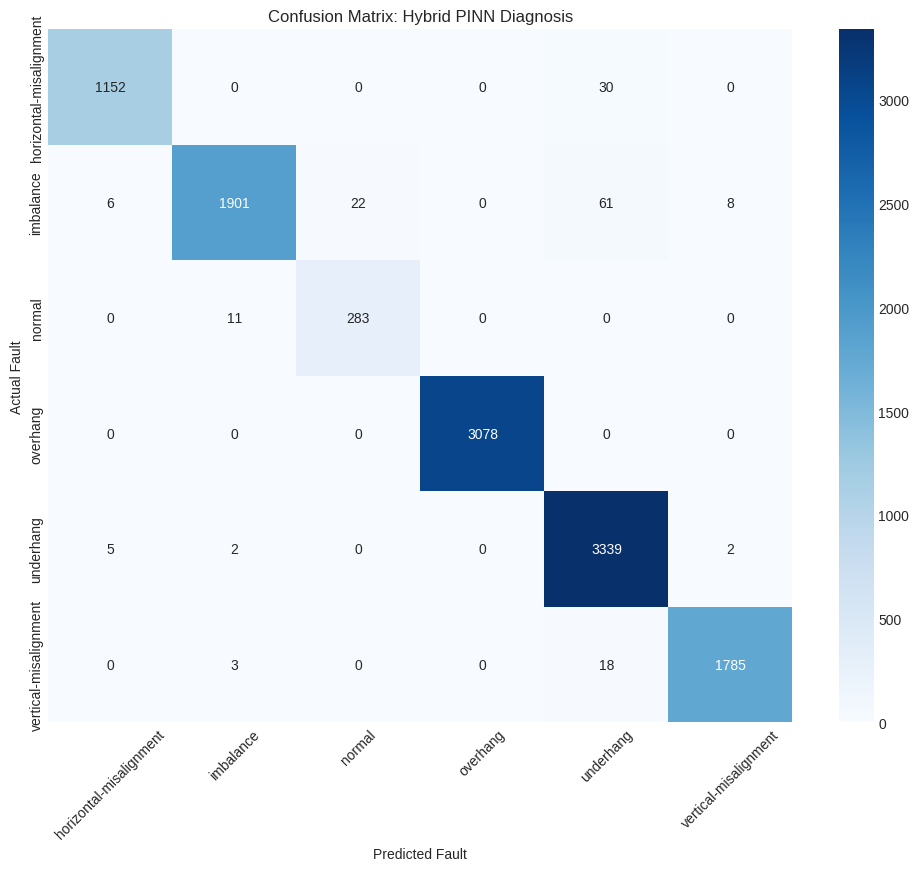


      Detailed Hybrid Classification Report
                         precision    recall  f1-score   support

horizontal-misalignment       0.99      0.97      0.98      1182
              imbalance       0.99      0.95      0.97      1998
                 normal       0.93      0.96      0.94       294
               overhang       1.00      1.00      1.00      3078
              underhang       0.97      1.00      0.98      3348
  vertical-misalignment       0.99      0.99      0.99      1806

               accuracy                           0.99     11706
              macro avg       0.98      0.98      0.98     11706
           weighted avg       0.99      0.99      0.99     11706



In [32]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    # تحويل الـ Mapping لعكسه (عشان نجيب الاسم من الرقم)
    # ملاحظة: لو بتستخدمي le_label.classes_ من خطوة الـ Preprocessing هيكون أضمن
    inv_label_map = {i: name for i, name in enumerate(le_label.classes_)}
    
    print(">>> Evaluating Hybrid PINN on Test Set...")
    with torch.no_grad():
        for batch in test_loader:
            # 1. نقل البيانات للجهاز
            x_acc = batch['x_acc'].to(DEVICE)
            # الـ features بتيجي جاهزة scaled من الـ Dataset المطور
            features = batch['features'].to(DEVICE)
            t = batch['t'].to(DEVICE)
            omega = batch['omega'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            
            # 2. الـ Forward Pass
            # الموديل الهجين بياخد (raw_sig, stat_feats, t, omega)
            logits, _ = model(x_acc, features, t, omega)
            preds = torch.argmax(logits, dim=1)
            
            # 3. تجميع النتائج
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # تحديد الأصناف اللي ظهرت فعلياً لتجنب الـ ValueError
    present_classes = np.unique(all_labels)
    present_names = [inv_label_map[i] for i in present_classes]
    
    # --- رسم الـ Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_names, 
                yticklabels=present_names)
    plt.title('Confusion Matrix: Hybrid PINN Diagnosis')
    plt.xlabel('Predicted Fault')
    plt.ylabel('Actual Fault')
    plt.xticks(rotation=45)
    plt.show()
    
    # --- طباعة التقرير النهائي ---
    print("\n" + "="*45)
    print("      Detailed Hybrid Classification Report")
    print("="*45)
    print(classification_report(all_labels, all_preds, 
                                labels=present_classes, 
                                target_names=present_names))

# تشغيل التقييم النهائي
evaluate_model(model, test_loader)

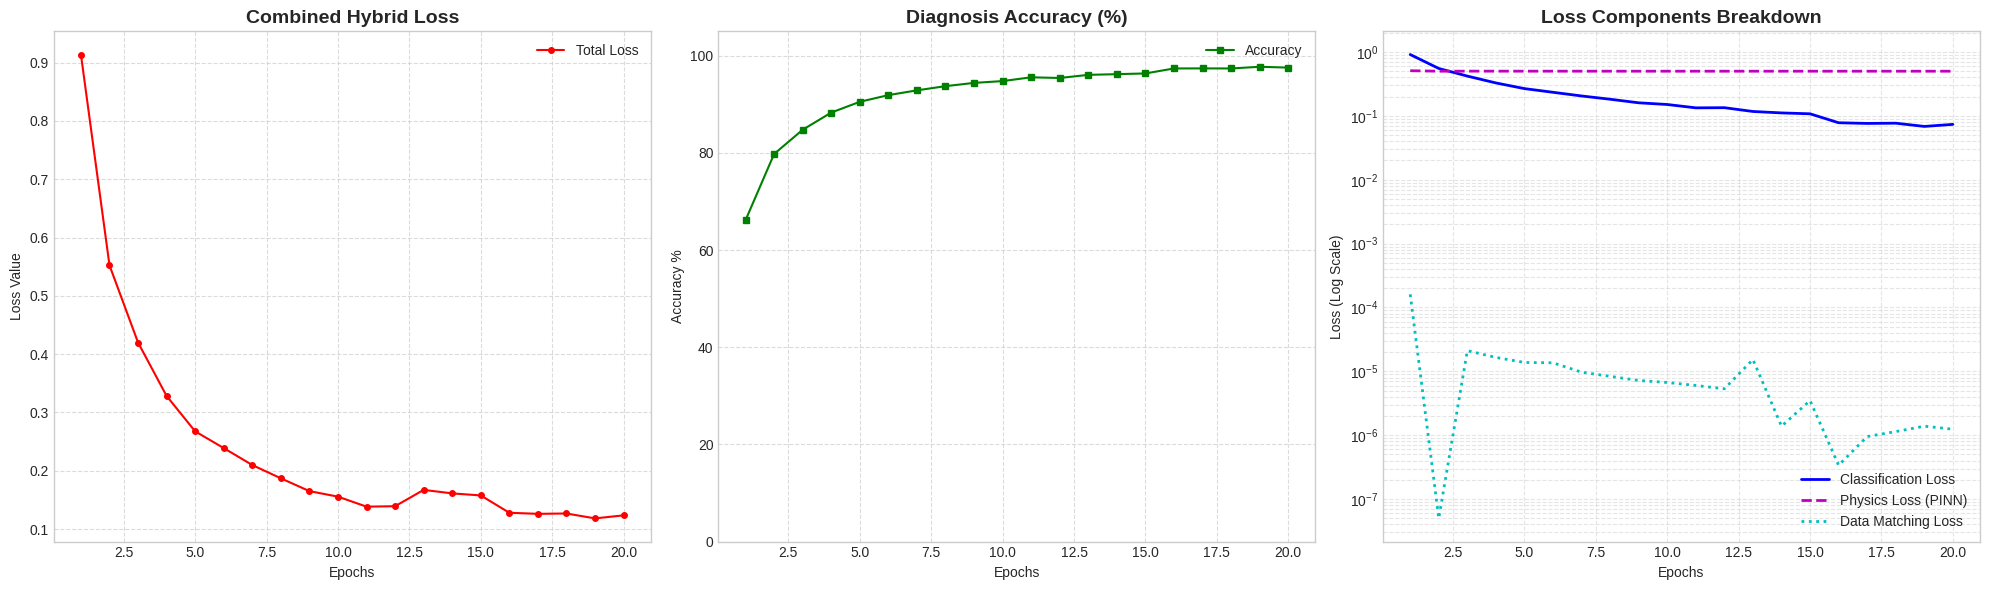

In [33]:
def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # زيادة حجم الشكل ليكون أكثر وضوحاً في التقارير
    plt.figure(figsize=(20, 6))
    plt.style.use('seaborn-v0_8-whitegrid') # ستايل نظيف واحترافي

    # 1. رسم الـ Total Combined Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', markersize=4, label='Total Loss')
    plt.title('Combined Hybrid Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2. رسم الـ Classification Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], 'g-s', markersize=4, label='Accuracy')
    plt.title('Diagnosis Accuracy (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy %')
    plt.ylim([0, 105]) # لضمان رؤية الثبات عند 100%
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 3. تحليل مكونات الـ Loss (التصنيف vs الفيزياء vs البيانات)
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['cls_loss'], 'b-', linewidth=2, label='Classification Loss')
    plt.plot(epochs, history['phys_loss'], 'm--', linewidth=2, label='Physics Loss (PINN)')
    
    # لو سجلنا الـ data_loss بنعرضها
    if 'data_loss' in history:
        plt.plot(epochs, history['data_loss'], 'c:', linewidth=2, label='Data Matching Loss')
    
    plt.title('Loss Components Breakdown', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Log Scale)')
    plt.yscale('log') # مهم جداً لرؤية الفروقات الصغيرة في الفيزياء
    plt.legend()
    plt.grid(True, which="both", linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)